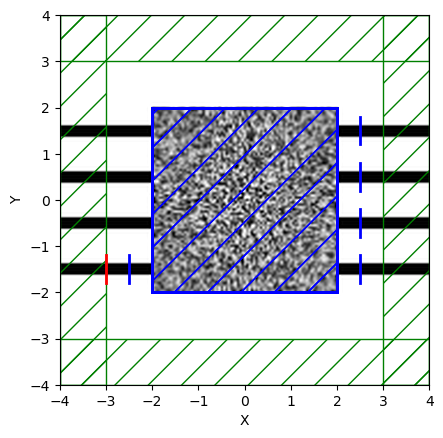

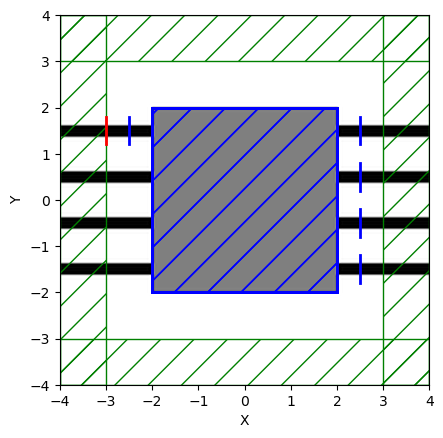

In [5]:
import meep as mp
import meep.adjoint as mpa
import numpy as np
from autograd import numpy as npa
from autograd import tensor_jacobian_product as vjp
from autograd import grad as ag_grad
import nlopt
import matplotlib.pyplot as plt

mp.verbosity(0)

Si = mp.Medium(index=3.4)

resolution = 20

# cell size
Sx = 8
Sy = 8
cell_size = mp.Vector3(Sx, Sy)
pml_layers = [mp.PML(1.0)]

# source
port_ys = [1.5, 0.5, -0.5, -1.5]

lambda_list = np.array([1.55, 1.56, 1.57, 1.58])
freq_list = 1 / lambda_list

width = 0.6
source_size = mp.Vector3(0, 0.6, 0)

source_x = -3

target_matrix = np.array([
    [1/4, 1/4, 1/4, 1/4],
    [0,   1/3, 1/3, 1/3],
    [0,   0,   1/2, 1/2],
    [0,   0,   0,   1  ],
])


def make_source(case_idx):
    """
    case_idx = 0: port 1 input, lambda = 1.55 um
    case_idx = 1: port 2 input, lambda = 1.56 um
    case_idx = 2: port 3 input, lambda = 1.57 um
    case_idx = 3: port 4 input, lambda = 1.58 um
    """

    fcen_case = freq_list[case_idx]
    fwidth_case = width * fcen_case

    src = mp.GaussianSource(
        frequency=fcen_case,
        fwidth=fwidth_case
    )

    source = [
        mp.EigenModeSource(
            src,
            eig_band=1,
            eig_match_freq=True,
            direction=mp.X,
            size=source_size,
            center=mp.Vector3(source_x, port_ys[case_idx], 0),
        )
    ]

    return source

#design region
Dx = 4
Dy = 4
design_region_resolution = int(resolution)

Nx = int(Dx * design_region_resolution) + 1
Ny = int(Dy * design_region_resolution) + 1

design_variables = mp.MaterialGrid(mp.Vector3(Nx,Ny),
                                   mp.air,
                                   Si,
                                   grid_type="U_MEAN")
design_region = mpa.DesignRegion(design_variables,
                                 volume=mp.Volume(center=mp.Vector3(),
                                                  size=mp.Vector3(Dx, Dy)))

# geometry
wg_width = 0.25

wg_length = (Sx - Dx) / 2

x_in = -Dx/2 - wg_length/2
x_out = Dx/2 + wg_length/2

geometry = []

# input / output waveguides
for y in port_ys:
    # input waveguide
    geometry.append(
        mp.Block(
            center=mp.Vector3(x_in, y),
            size=mp.Vector3(wg_length, wg_width, mp.inf),
            material=Si
        )
    )

    # output waveguide
    geometry.append(
        mp.Block(
            center=mp.Vector3(x_out, y),
            size=mp.Vector3(wg_length, wg_width, mp.inf),
            material=Si
        )
    )

# OSU design region
geometry.append(
    mp.Block(
        center=design_region.center,
        size=design_region.size,
        material=design_variables
    )
)

# FOM
def make_J(case_idx):

    target = npa.array(target_matrix[case_idx])
    target_norm = npa.mean(target ** 2) + 1e-12

    def J(a_in, a1, a2, a3, a4):
        Pin = npa.squeeze(npa.abs(a_in) ** 2) + 1e-12

        powers = npa.array([
            npa.squeeze(npa.abs(a1) ** 2),
            npa.squeeze(npa.abs(a2) ** 2),
            npa.squeeze(npa.abs(a3) ** 2),
            npa.squeeze(npa.abs(a4) ** 2)
        ])

        T = powers / Pin

        mse = npa.mean((T - target) ** 2)

        fom = 1 - mse / target_norm

        return fom

    return J


opt_list = []

for case_idx in range(4):

    fcen = freq_list[case_idx]
    source = make_source(case_idx)

    sim = mp.Simulation(
        cell_size=cell_size,
        boundary_layers=pml_layers,
        geometry=geometry,
        sources=source,
        eps_averaging=False,
        resolution=resolution,
    )

    # input monitor
    TE_in = mpa.EigenmodeCoefficient(
        sim,
        mp.Volume(
            center=mp.Vector3(-2.5, port_ys[case_idx], 0),
            size=mp.Vector3(y=0.6)
        ),
        mode=1,
        forward=True
    )

    # output monitors
    TE_out = []

    for y in port_ys:
        TE_out.append(
            mpa.EigenmodeCoefficient(
                sim,
                mp.Volume(
                    center=mp.Vector3(2.5, y, 0),
                    size=mp.Vector3(y=0.6)
                ),
                mode=1
            )
        )

    ob_list = [TE_in] + TE_out

    J_case = make_J(case_idx)

    opt = mpa.OptimizationProblem(
        simulation=sim,
        objective_functions=J_case,
        objective_arguments=ob_list,
        design_regions=[design_region],
        fcen=fcen,
        df=0,
        nf=1,
    )

    opt_list.append(opt)

x0 = np.random.rand(Nx * Ny)
opt.update_design([x0])

opt.plot2D(True, frequency=1 / 1.55)
plt.show()

x0 = 0.5 * np.ones((Nx * Ny,))

for opt_case in opt_list:
    opt_case.update_design([x0])

opt_list[0].plot2D(True, frequency=freq_list[0])
plt.show()


In [6]:
evaluation_history = []
case_history = []
cur_iter = [0]

num_design_variables = Nx * Ny
num_cases = len(opt_list)

case_weights = np.ones(num_cases) / num_cases


def get_gradient_array(dJ_du):
    g = dJ_du

    while isinstance(g, (list, tuple)):
        g = g[0]

    g = np.real(np.squeeze(np.asarray(g)))
    g = g.reshape(-1)

    return g


def f(v, gradient):
    cur_iter[0] += 1

    total_fom = 0.0
    total_grad = np.zeros(num_design_variables)

    case_foms = []
    for case_idx, opt_case in enumerate(opt_list):

        fom_i, dJ_du_i = opt_case([v], need_gradient=True)

        fom_i = float(np.real(np.squeeze(fom_i)))
        g_i = get_gradient_array(dJ_du_i)

        if g_i.size != num_design_variables:
            raise ValueError(
                f"Gradient size mismatch at case {case_idx}: "
                f"got {g_i.size}, expected {num_design_variables}"
            )

        w = case_weights[case_idx]

        total_fom += w * fom_i
        total_grad += w * g_i

        case_foms.append(fom_i)

    if gradient.size > 0:
        gradient[:] = total_grad

    evaluation_history.append(total_fom)
    case_history.append(case_foms)

    print(
        f"iter {cur_iter[0]:03d} | "
        f"FOM = {total_fom:.8f} | "
        f"cases = [{case_foms[0]:.4f}, {case_foms[1]:.4f}, "
        f"{case_foms[2]:.4f}, {case_foms[3]:.4f}]"
    )

    return total_fom


algorithm = nlopt.LD_MMA
solver = nlopt.opt(algorithm, Nx * Ny)
solver.set_lower_bounds(np.zeros(Nx * Ny))
solver.set_upper_bounds(np.ones(Nx * Ny))
solver.set_max_objective(f)
solver.set_maxeval(100)
solver.set_ftol_rel(1e-5)

x = solver.optimize(x0)

x = np.clip(x, 0.0, 1.0)


for opt_case in opt_list:
    opt_case.update_design([x])


Starting forward run...


Starting adjoint run...


Calculating gradient...
Starting forward run...


Starting adjoint run...


Calculating gradient...
Starting forward run...


...

Calculating gradient...
Starting forward run...


Starting adjoint run...


Calculating gradient...
Starting forward run...


Starting adjoint run...


Calculating gradient...
iter 100 | FOM = 0.99106803 | cases = [0.9951, 0.9940, 0.9875, 0.9877]


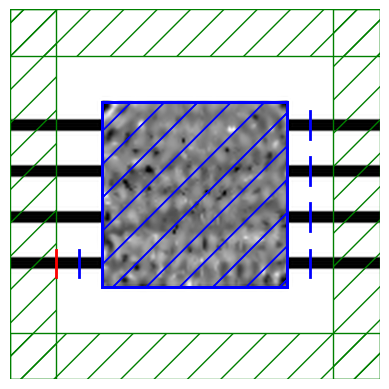

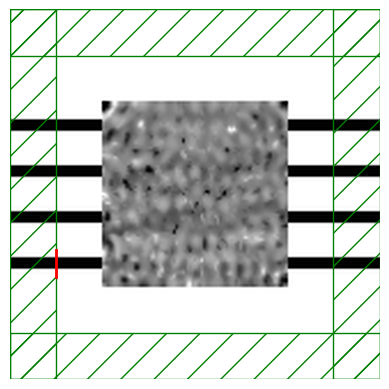

In [7]:
opt.update_design([x])
opt.plot2D(
    True,
    plot_monitors_flag=False,
    output_plane=mp.Volume(center=(0,0,0), size=(8,8,0))
)
plt.axis("off")

opt.update_design([x])

plt.figure()
sim.plot2D(
    output_plane=mp.Volume(center=mp.Vector3(), size=mp.Vector3(8,8,0)),
    labels=False
)
plt.axis("off")
plt.show()

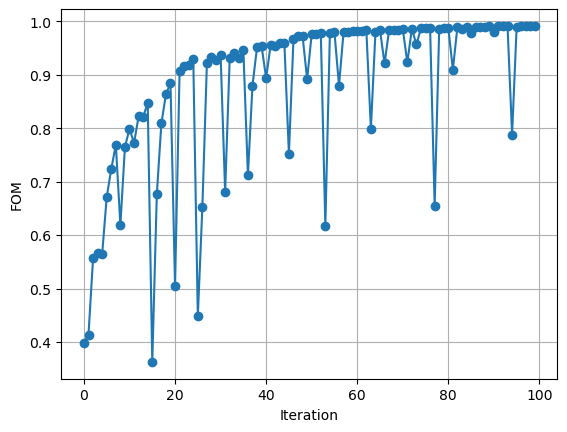

In [8]:
plt.figure()
plt.plot(evaluation_history, "o-")
plt.grid(True)
plt.xlabel("Iteration")
plt.ylabel("FOM")
plt.show()

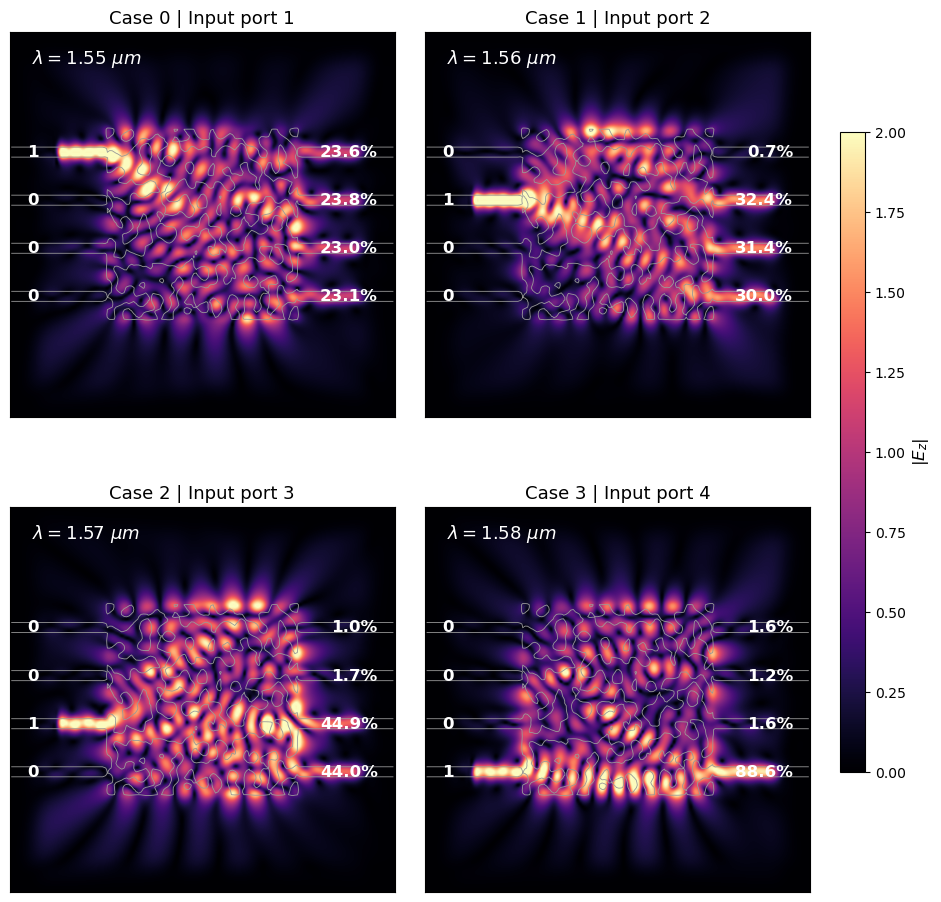

<Figure size 640x480 with 0 Axes>

Transmission summary

Case 0
Input port: 1
Lambda: 1.55 um
T1 = 23.63%
T2 = 23.79%
T3 = 22.97%
T4 = 23.15%
Target:
target 1 = 0.25
target 2 = 0.25
target 3 = 0.25
target 4 = 0.25

Case 1
Input port: 2
Lambda: 1.56 um
T1 = 0.72%
T2 = 32.36%
T3 = 31.40%
T4 = 30.02%
Target:
target 1 = 0.0
target 2 = 0.3333333333333333
target 3 = 0.3333333333333333
target 4 = 0.3333333333333333

Case 2
Input port: 3
Lambda: 1.57 um
T1 = 1.04%
T2 = 1.70%
T3 = 44.89%
T4 = 44.00%
Target:
target 1 = 0.0
target 2 = 0.0
target 3 = 0.5
target 4 = 0.5

Case 3
Input port: 4
Lambda: 1.58 um
T1 = 1.58%
T2 = 1.21%
T3 = 1.57%
T4 = 88.56%
Target:
target 1 = 0.0
target 2 = 0.0
target 3 = 0.0
target 4 = 1.0


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import meep as mp

# Plot할 design 선택
design_to_plot = x  # 최적화 후 구조: x, 초기 구조: x0

# Design variable 생성
plot_design_variables = mp.MaterialGrid(
    mp.Vector3(Nx, Ny),
    mp.air,
    Si,
    weights=design_to_plot.reshape((Nx, Ny)),
    grid_type="U_MEAN"
)

# Geometry 생성
geometry_plot = []

for y in port_ys:
    geometry_plot.append(
        mp.Block(
            center=mp.Vector3(x_in, y),
            size=mp.Vector3(wg_length, wg_width, mp.inf),
            material=Si
        )
    )

    geometry_plot.append(
        mp.Block(
            center=mp.Vector3(x_out, y),
            size=mp.Vector3(wg_length, wg_width, mp.inf),
            material=Si
        )
    )

geometry_plot.append(
    mp.Block(
        center=design_region.center,
        size=design_region.size,
        material=plot_design_variables
    )
)

# 4개 case를 한 figure에 표시
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.ravel()

# Transmission 결과 저장
all_T = []

# 모든 case 실행
for case_idx in range(4):

    fcen_case = freq_list[case_idx]
    lambda_case = lambda_list[case_idx]
    input_y = port_ys[case_idx]
    target_case = target_matrix[case_idx]

    # Case별 source 생성
    source_case = make_source(case_idx)

    # Case별 simulation 생성
    sim_plot = mp.Simulation(
        cell_size=cell_size,
        boundary_layers=pml_layers,
        geometry=geometry_plot,
        sources=source_case,
        eps_averaging=False,
        resolution=resolution,
    )

    # Input flux monitor
    input_flux = sim_plot.add_flux(
        fcen_case, 0, 1,
        mp.FluxRegion(
            center=mp.Vector3(-2.5, input_y, 0),
            size=mp.Vector3(0, 0.6, 0)
        )
    )

    # Output flux monitors
    output_flux_1 = sim_plot.add_flux(
        fcen_case, 0, 1,
        mp.FluxRegion(
            center=mp.Vector3(2.5, port_ys[0], 0),
            size=mp.Vector3(0, 0.6, 0)
        )
    )

    output_flux_2 = sim_plot.add_flux(
        fcen_case, 0, 1,
        mp.FluxRegion(
            center=mp.Vector3(2.5, port_ys[1], 0),
            size=mp.Vector3(0, 0.6, 0)
        )
    )

    output_flux_3 = sim_plot.add_flux(
        fcen_case, 0, 1,
        mp.FluxRegion(
            center=mp.Vector3(2.5, port_ys[2], 0),
            size=mp.Vector3(0, 0.6, 0)
        )
    )

    output_flux_4 = sim_plot.add_flux(
        fcen_case, 0, 1,
        mp.FluxRegion(
            center=mp.Vector3(2.5, port_ys[3], 0),
            size=mp.Vector3(0, 0.6, 0)
        )
    )

    # Field monitor
    dft_fields = sim_plot.add_dft_fields(
        [mp.Ez],
        fcen_case,
        0,
        1,
        center=mp.Vector3(),
        size=cell_size
    )

    # Simulation 실행
    sim_plot.run(
        until_after_sources=mp.stop_when_fields_decayed(
            50,
            mp.Ez,
            mp.Vector3(2.5, input_y, 0),
            1e-6
        )
    )

    # Field와 dielectric data 추출
    ez_dft = sim_plot.get_dft_array(dft_fields, mp.Ez, 0)

    eps_data = sim_plot.get_array(
        center=mp.Vector3(),
        size=cell_size,
        component=mp.Dielectric
    )

    # Field intensity 정규화
    field_amp = np.abs(ez_dft)

    vref = np.percentile(field_amp, 99.5)
    field_plot = field_amp / (vref + 1e-12) * 2.0
    field_plot = np.clip(field_plot, 0, 2.0)

    # Input 기준 transmission 계산
    Pin = mp.get_fluxes(input_flux)[0]
    Pin = max(Pin, 1e-12)

    Pout1 = max(mp.get_fluxes(output_flux_1)[0], 0)
    Pout2 = max(mp.get_fluxes(output_flux_2)[0], 0)
    Pout3 = max(mp.get_fluxes(output_flux_3)[0], 0)
    Pout4 = max(mp.get_fluxes(output_flux_4)[0], 0)

    T1 = Pout1 / Pin
    T2 = Pout2 / Pin
    T3 = Pout3 / Pin
    T4 = Pout4 / Pin

    T_values = [T1, T2, T3, T4]
    all_T.append(T_values)

    # 현재 case의 subplot 선택
    ax = axes[case_idx]

    # Field plot
    im = ax.imshow(
        field_plot.T,
        origin="lower",
        cmap="magma",
        extent=[-Sx/2, Sx/2, -Sy/2, Sy/2],
        interpolation="spline36",
        vmin=0,
        vmax=2.0
    )

    # Structure contour
    eps_air = 1.0
    eps_si = 3.4**2
    eps_level = (eps_air + eps_si) / 2

    ax.contour(
        eps_data.T,
        levels=[eps_level],
        colors="0.6",
        linewidths=0.6,
        origin="lower",
        extent=[-Sx/2, Sx/2, -Sy/2, Sy/2]
    )

    # Input port label
    for i, y in enumerate(port_ys):
        input_label = "1" if i == case_idx else "0"

        ax.text(
            -Sx/2 + 0.35,
            y,
            input_label,
            color="white",
            fontsize=12,
            ha="left",
            va="center",
            weight="bold"
        )

    # Output transmission label
    for i, y in enumerate(port_ys):
        ax.text(
            Sx/2 - 0.35,
            y,
            f"{100 * T_values[i]:.1f}%",
            color="white",
            fontsize=12,
            ha="right",
            va="center",
            weight="bold"
        )

    # Wavelength label
    ax.text(
        -Sx/2 + 0.45,
        Sy/2 - 0.65,
        rf"$\lambda = {lambda_case:.2f}\ \mu m$",
        color="white",
        fontsize=13,
        weight="bold"
    )

    ax.set_title(
        f"Case {case_idx} | Input port {case_idx + 1}",
        fontsize=13
    )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim([-Sx/2, Sx/2])
    ax.set_ylim([-Sy/2, Sy/2])

# Colorbar
# Subplot 간격과 오른쪽 여백 조정
fig.subplots_adjust(
    left=0.04,
    right=0.84,
    bottom=0.04,
    top=0.94,
    wspace=0.08,
    hspace=0.12
)

# Colorbar 위치를 별도 축으로 고정
cbar_ax = fig.add_axes([0.87, 0.18, 0.025, 0.64])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label(r"$|E_z|$", fontsize=12)

plt.show()

plt.tight_layout()
plt.show()

# Transmission summary 출력
print("Transmission summary")

for case_idx in range(4):
    print()
    print(f"Case {case_idx}")
    print(f"Input port: {case_idx + 1}")
    print(f"Lambda: {lambda_list[case_idx]:.2f} um")

    print(f"T1 = {100 * all_T[case_idx][0]:.2f}%")
    print(f"T2 = {100 * all_T[case_idx][1]:.2f}%")
    print(f"T3 = {100 * all_T[case_idx][2]:.2f}%")
    print(f"T4 = {100 * all_T[case_idx][3]:.2f}%")

    print("Target:")
    print(f"target 1 = {target_matrix[case_idx][0]}")
    print(f"target 2 = {target_matrix[case_idx][1]}")
    print(f"target 3 = {target_matrix[case_idx][2]}")
    print(f"target 4 = {target_matrix[case_idx][3]}")